Category Accuracy: 0.3333333333333333
Priority Accuracy: 0.3333333333333333

Classification Report:

              precision    recall  f1-score   support

     Billing       0.00      0.00      0.00         0
   Technical       1.00      0.33      0.50         3

    accuracy                           0.33         3
   macro avg       0.50      0.17      0.25         3
weighted avg       1.00      0.33      0.50         3



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


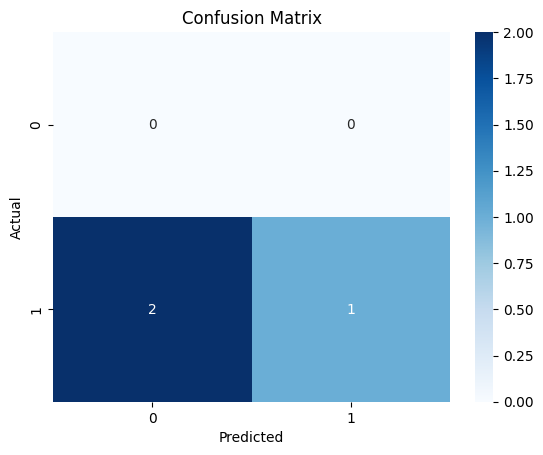

Ticket: payment issue urgent
Category: Billing
Priority: High


In [ ]:
import pandas as pd
import re
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
data = {
    'text': [
        'internet not working properly',
        'very slow network speed',
        'want refund for wrong charge',
        'billing issue in my account',
        'application keeps crashing frequently',
        'login error unable to access account',
        'payment failed but money deducted',
        'server down urgent fix needed',
        'app not opening after update',
        'incorrect billing amount charged'
    ],
    'category': [
        'Technical','Technical','Billing','Billing',
        'Technical','Technical','Billing','Technical',
        'Technical','Billing'
    ],
    'priority': [
        'High','Medium','Medium','Low',
        'High','High','High','High',
        'Medium','Medium'
    ]
}

df = pd.DataFrame(data)

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z ]', '', text)
    return text

df['text'] = df['text'].apply(clean_text)

X_train, X_test, y_cat_train, y_cat_test = train_test_split(
    df['text'], df['category'], test_size=0.25, random_state=42
)

_, _, y_pri_train, y_pri_test = train_test_split(
    df['text'], df['priority'], test_size=0.25, random_state=42
)

cat_model = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('model', MultinomialNB())
])

pri_model = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('model', MultinomialNB())
])

cat_model.fit(X_train, y_cat_train)
pri_model.fit(X_train, y_pri_train)

cat_pred = cat_model.predict(X_test)
pri_pred = pri_model.predict(X_test)

print("Category Accuracy:", accuracy_score(y_cat_test, cat_pred))
print("Priority Accuracy:", accuracy_score(y_pri_test, pri_pred))

print("\nClassification Report:\n")
print(classification_report(y_cat_test, cat_pred))

cm = confusion_matrix(y_cat_test, cat_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

def predict_ticket(text):
    text = clean_text(text)
    category = cat_model.predict([text])[0]
    priority = pri_model.predict([text])[0]

    print("Ticket:", text)
    print("Category:", category)
    print("Priority:", priority)

# Example
predict_ticket("payment issue urgent")



**Support Ticket Classification and Priority Prediction System**
This project presents a machine learning-based system that automatically classifies customer support tickets into categories such as Technical and Billing. Additionally, it predicts the priority level (High, Medium, Low) based on the urgency of the issue. The system uses Natural Language Processing techniques including text preprocessing and TF-IDF vectorization, combined with a Naive Bayes classifier. Model performance is evaluated using accuracy metrics and a confusion matrix. This solution can help automate customer support workflows and improve response efficiency.